# Agglomerative Hierarchical Clustering 🏢

In this notebook, we implement **Agglomerative Hierarchical Clustering**, a bottom-up clustering method.

## 📖 Theoretical Background

The algorithm builds a hierarchy of clusters by iteratively merging the closest pairs of clusters until a desired number of clusters ($K$) is reached.

### 1. Initialization
Start by treating each data point as a single cluster.

### 2. Distance Computation
Compute the distance between all pairs of clusters. 

### 3. Linkage Criteria
To measure the distance between two clusters (which may contain multiple points), we use a linkage criterion. Common ones include:
- **Single Linkage**: Distance between the closest members of the two clusters.
- **Complete Linkage**: Distance between the farthest members.
- **Average Linkage**: Average distance between all members.

Here, we will implement **Single Linkage**.

### 4. Merging
Merge the two clusters that are closest to each other according to the linkage criterion. Update the distance matrix. Repeat until only $K$ clusters remain.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

np.random.seed(42)

## 🏗️ The Implementation

In [2]:
class AgglomerativeClustering:
    def __init__(self, n_clusters=2):
        self.n_clusters = n_clusters
        self.labels_ = None
        
    def fit_predict(self, X):
        n_samples = X.shape[0]
        
        # Initialize each point as its own cluster
        clusters = {i: [i] for i in range(n_samples)}
        
        # Precompute pairwise distances between all points
        # Shape: (n_samples, n_samples)
        distances = np.zeros((n_samples, n_samples))
        for i in range(n_samples):
            for j in range(i + 1, n_samples):
                dist = np.linalg.norm(X[i] - X[j])
                distances[i, j] = dist
                distances[j, i] = dist
                
        # To prevent merging a cluster with itself, set diagonal to infinity
        np.fill_diagonal(distances, np.inf)
        
        current_clusters = n_samples
        
        while current_clusters > self.n_clusters:
            # Find the two closest clusters
            # We look for the minimum distance in the distance matrix
            min_dist = np.inf
            c1, c2 = -1, -1
            
            # Only compare existing clusters
            cluster_ids = list(clusters.keys())
            
            for i in range(len(cluster_ids)):
                for j in range(i + 1, len(cluster_ids)):
                    id1, id2 = cluster_ids[i], cluster_ids[j]
                    
                    # Single linkage: minimum distance between any point in c1 and any point in c2
                    dist = np.min(distances[np.ix_(clusters[id1], clusters[id2])])
                    
                    if dist < min_dist:
                        min_dist = dist
                        c1, c2 = id1, id2
                        
            # Merge c2 into c1
            clusters[c1].extend(clusters[c2])
            del clusters[c2]
            
            current_clusters -= 1
            
        # Reassign labels
        self.labels_ = np.zeros(n_samples, dtype=int)
        for label, (cluster_id, points) in enumerate(clusters.items()):
            for point in points:
                self.labels_[point] = label
                
        return self.labels_


## 🧪 Data Generation and Training
We test our hierarchical clustering on a 3-blob dataset.

In [3]:
X, y = make_blobs(n_samples=150, centers=3, cluster_std=1.0, random_state=42)

# It takes O(N^3) naive, so 150 points is fast enough.
hc = AgglomerativeClustering(n_clusters=3)
labels = hc.fit_predict(X)

## 📊 Visualization

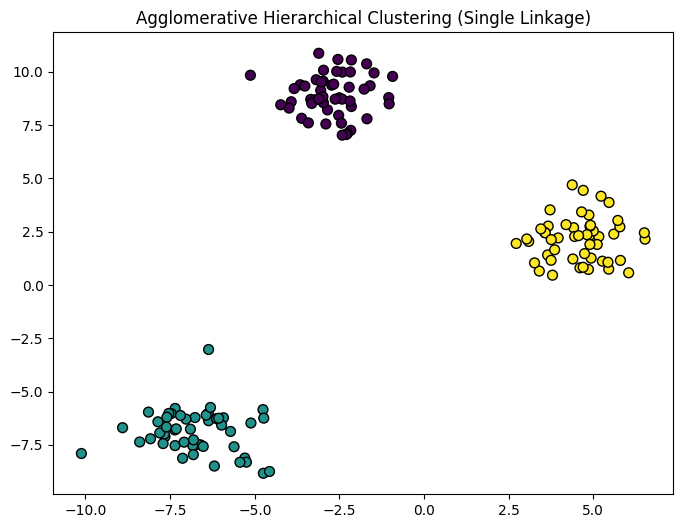

In [4]:
plt.figure(figsize=(8, 6))

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolors='k', s=50)
plt.title('Agglomerative Hierarchical Clustering (Single Linkage)')
plt.show()